# In this file I explain the methodology and results of the task

# The Data

There are many public datasets which provide time-series data labelled with some form of "incident" or "anomaly". However, for this mini project I decided to use the [NAB dataset](https://github.com/numenta/NAB/tree/master). More specifically, I used the [nyctraffic dataset](https://github.com/numenta/NAB/blob/master/data/realKnownCause/nyc_taxi.csv) which features real data about the number of passengers in NYC taxis from 01/07/2014 to 31/01/2015 split by 30 minute intervals. To get a feel for how the data looks we can quickly plot it below.

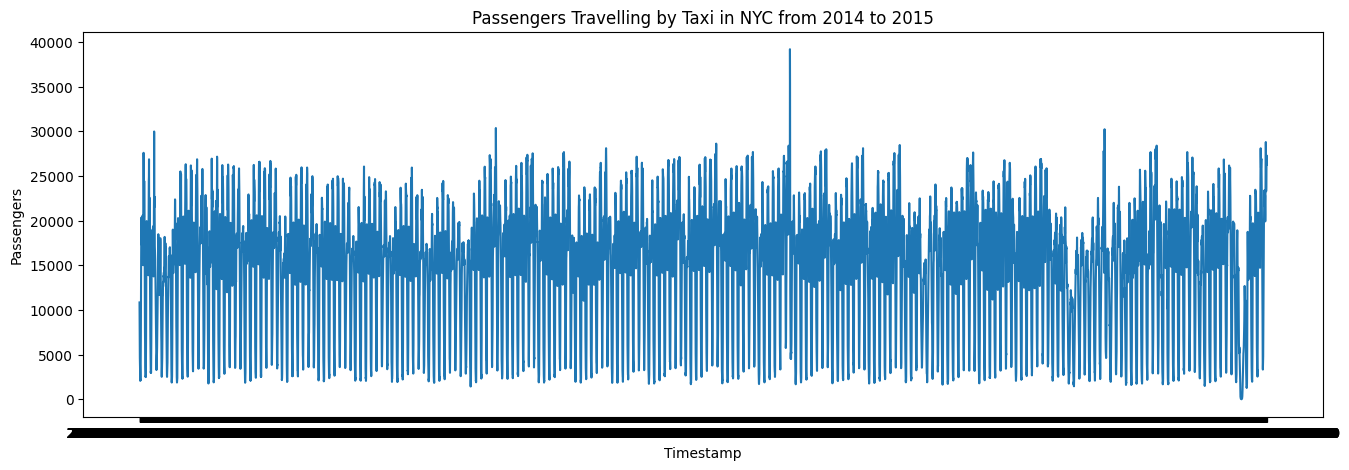

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/numenta/NAB/master/data/realKnownCause/nyc_taxi.csv")

plt.figure(figsize=(16, 5)) 
plt.plot(df["timestamp"], df["value"])
plt.xlabel("Timestamp")
plt.ylabel("Passengers")
plt.title("Passengers Travelling by Taxi in NYC from 2014 to 2015")
plt.show()

There is an explainable pattern going on with peak hours experiencing the most passengers and the middle of the night experiencing the fewest. However most data is concentrated somewhere in the middle which is the average day/hour passenger number. However, what is interesting for our problem is that there are some abnormal peaks and periods of less traffic observed. To see how they align with how the dataset is labelled have a look at the graph below:

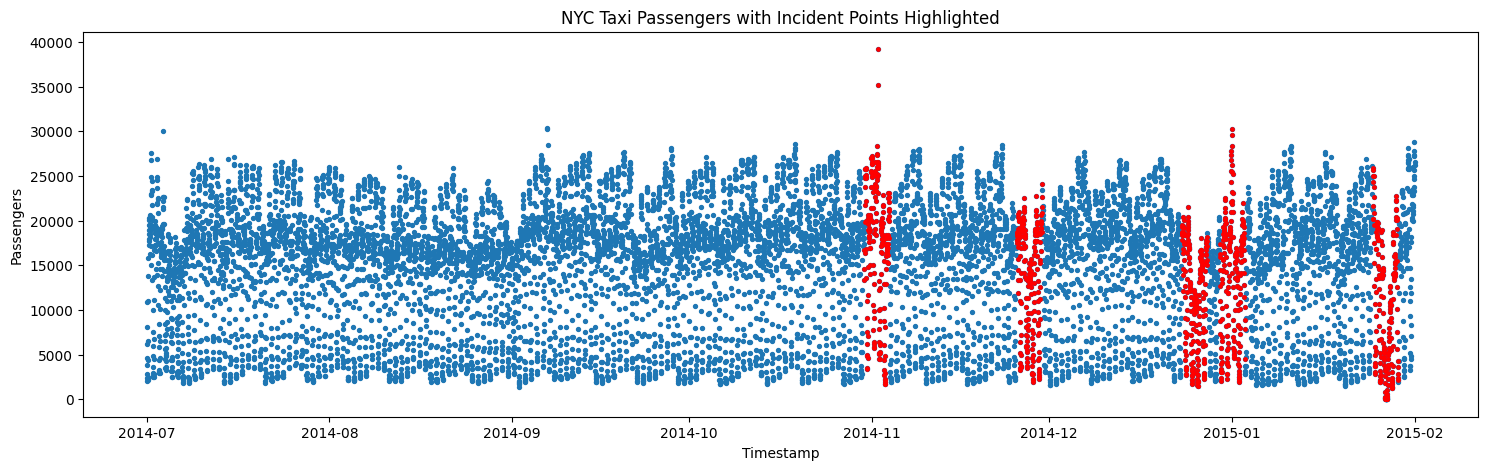

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import json

df = pd.read_csv("https://raw.githubusercontent.com/numenta/NAB/master/data/realKnownCause/nyc_taxi.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["is_incident"] = 0

labels_path = "combined_windows.json"

with open(labels_path, "r") as f:
    all_labels = json.load(f)
    nyc_windows = all_labels.get("realKnownCause/nyc_taxi.csv", [])

for start, end in nyc_windows:
    start_date = pd.to_datetime(start)
    end_date = pd.to_datetime(end)
    mask = (df["timestamp"] >= start_date) & (df["timestamp"] <= end_date)
    df.loc[mask, "is_incident"] = 1

incident = df[df["is_incident"] == 1]

plt.figure(figsize=(18, 5))

plt.scatter(df["timestamp"], df["value"], s=8, label="all points")
plt.scatter(incident["timestamp"], incident["value"], color="red", s=6, label="incident")

plt.xlabel("Timestamp")
plt.ylabel("Passengers")
plt.title("NYC Taxi Passengers with Incident Points Highlighted")
plt.show()

Although maybe not perfectly visible, we see that in fact the 2 largest peaks and multiple periods of lower traffic were in fact labelled as "anomalies". For the interested reader they are the following: 
- November 2, 2014 : The NYC Marathon
- November 27, 2014: Thanksgiving
- December 25, 2015: Christmas Day
- January 1, 2015: New Year's Day
- January 26-28, 2015: North American Blizzard


Now we move on to selecting and training a model in hopes of being able to predict upcoming incidents/anomalies in the next *H* timesteps by looking at the previous *W* timesteps. Many models that can solve this task exist, however I decided to go with XGBoost as after preprocessing that data we will see that this essentially turns into tabular data with multiple features and a label. XGBoost is a strong model for this task. Furthermore, XGBoost will provide interesting insights as to identifying which of the features are most important for the prediction. Since we have the previous time *W* timesteps as features we will hopefully be able to tell how far back is it most important to look to detect an anomaly. However before we begin training and evaluating our model we must preprocess the data.

In [9]:
import data_processing as dp

labels_path = "combined_windows.json"
dp.create_windowed_dataset(4,2, labels_path)

df = pd.read_csv("data.csv")
print(df.head())

             timestamp    t-4   t-3   t-2   t-1  hour  day_of_week  month  \
0  2014-07-01 02:00:00  10844  8127  6210  4656     2            1      7   
1  2014-07-01 02:30:00   8127  6210  4656  3820     2            1      7   
2  2014-07-01 03:00:00   6210  4656  3820  2873     3            1      7   
3  2014-07-01 03:30:00   4656  3820  2873  2369     3            1      7   
4  2014-07-01 04:00:00   3820  2873  2369  2064     4            1      7   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


As can be seen above we now have the data organized in a csv file with multiple features including the last *W* timestep values as well as additional possibly relevant features such as the hour, day of the week and month. Each row has a target where 0 indicated no anomaly and 1 means that an anomoly is present. For each timestamp the target was set to 1 if there is an anomaly in any of the next *H* timesteps. For more details see the data_processing.py file.

# The Model

As stated above the model we have chosen is XGBoost. Its implementation can be done fairly simply through the use of the [xgboost library](https://xgboost.readthedocs.io/en/latest/python/index.html). We will do so below:

In [10]:
import model as md

model, X_test, y_test = md.train_xgboost()

The details can be read in model.py, however what is done is the data is split into inputs (everything except the timestamp and target) and our target outputs and then trained.

# The Evaluation

Since this is a binary classification in order to evaluate the model's performance we will use common metrics used in these types of problems. The metrics utilized are the general accuracy of the model, the precision, the recall, the F1-score, the AUROC and a confusion matrix to better visualize the results.

In [11]:
import evaluation

evaluation.evaluate(model, X_test, y_test, 0.05)

Accuracy Score: 0.7926 (79.26%)
AUROC Score: 0.7374
F1-score: 0.2517

Confusion Matrix
[[1173    0]
 [ 321   54]]

Classification Report
              precision    recall  f1-score   support

           0       0.79      1.00      0.88      1173
           1       1.00      0.14      0.25       375

    accuracy                           0.79      1548
   macro avg       0.89      0.57      0.57      1548
weighted avg       0.84      0.79      0.73      1548



Before we fully analyze the results, an important point has to be addressed. At the start of this document I selected W and H as 4 and 2 respectively. However, these are hyperparameters of this problem and they can be tuned to obtain better results on this specific dataset. Therefore, before we analyze the results for an arbitrary selection of W and H, let us verify which selection of these hyperparameters performs best on the taxi dataset. One of the common ways to do this is a grid search, selecting numbers that represent logical time intervals (1 hours, 2 hours, 6 hours, 12 hours, 24 hours). As taking windows larger than that is unlikely to affect the data going forwards. The size of the prediction window is smaller as it becomes increasingly difficult to predict further into the future. All that is left to do is to choose a metric to evaluate each combination on, and here for completness I chose to select the combinations which gave the highest AUROC score and highest F1-score.

In [12]:
import grid_search as gs

best_auroc, best_params_auroc, best_model_info_auroc, best_f1, best_params_f1, best_model_info_f1 = gs.grid_search_on_W_H(0.05) # The parameter is the threshold parameter and will be explained later

W = 2, H = 1
AUROC: 0.6985
F1: 0.2364066193853428

W = 2, H = 2
AUROC: 0.7073
F1: 0.24355971896955503

W = 2, H = 4
AUROC: 0.7396
F1: 0.24537037037037038

W = 4, H = 1
AUROC: 0.6989
F1: 0.2447058823529412

W = 4, H = 2
AUROC: 0.7374
F1: 0.2517482517482518

W = 4, H = 4
AUROC: 0.7275
F1: 0.25

W = 12, H = 1
AUROC: 0.7561
F1: 0.24528301886792453

W = 12, H = 2
AUROC: 0.7963
F1: 0.2447058823529412

W = 12, H = 4
AUROC: 0.7736
F1: 0.2383177570093458

W = 24, H = 1
AUROC: 0.8064
F1: 0.25471698113207547

W = 24, H = 2
AUROC: 0.8146
F1: 0.2576112412177986

W = 24, H = 4
AUROC: 0.7970
F1: 0.2558139534883721

W = 48, H = 1
AUROC: 0.8440
F1: 0.2571428571428571

W = 48, H = 2
AUROC: 0.8325
F1: 0.26004728132387706

W = 48, H = 4
AUROC: 0.8235
F1: 0.26573426573426573

Best W and H for AUROC: W = 48, H = 1
Best AUROC: 0.8440
Best W and H for F1: W = 48, H = 4
Best F1: 0.2657


We see from the results that the two best combinations are W=48, H=1 and W=48, H=4. This seems to be logical as it appears that the more data we have the more confident the prediction about the future becomes. Lets look more closely at the results from these two combinations.

In [14]:
import evaluation as eval

print(f"Data for W = 48 and H = 1")
eval.evaluate(best_model_info_auroc[0], best_model_info_auroc[1], best_model_info_auroc[2], 0.05)

Data for W = 48 and H = 1
Accuracy Score: 0.7975 (79.75%)
AUROC Score: 0.8440
F1-score: 0.2571

Confusion Matrix
[[1175    0]
 [ 312   54]]

Classification Report
              precision    recall  f1-score   support

           0       0.79      1.00      0.88      1175
           1       1.00      0.15      0.26       366

    accuracy                           0.80      1541
   macro avg       0.90      0.57      0.57      1541
weighted avg       0.84      0.80      0.73      1541



In [16]:
import evaluation as eval
print(f"Data for W = 48 and H = 4")
eval.evaluate(best_model_info_f1[0], best_model_info_f1[1], best_model_info_f1[2], 0.05)

Data for W = 48 and H = 4
Accuracy Score: 0.7956 (79.56%)
AUROC Score: 0.8235
F1-score: 0.2657

Confusion Matrix
[[1169    0]
 [ 315   57]]

Classification Report
              precision    recall  f1-score   support

           0       0.79      1.00      0.88      1169
           1       1.00      0.15      0.27       372

    accuracy                           0.80      1541
   macro avg       0.89      0.58      0.57      1541
weighted avg       0.84      0.80      0.73      1541



As is evident for both cases the AUROC looks quite positive ranfing from 0.8 to 0.85. This indicates that we are able to distinguish between positive cases and negative cases fairly well. However, what is immediately alarming is that even for the model with the best possible possible F1-score it is only at 0.2657. This is low. Since we know that this score is dependent on the precision and recall we further analyze those. Firstly, looking at the precision we see that it is fairly high meaning that we do not incorrectly label the true cases, and in fact we never state that an anomaly occured when in reality it didnt. Therefore, the issue must be the recall. As we can see the recall is very low for predicting the anomaly case. This means that the majority (over 80% of cases) the anomaly goes undetected. This can be further observed in the confusion matrices of both cases where over 300 anomaly cases go undetected. This is a potential problem. However since our AUROC scores are promising we can try lowering the requiered confidence to predict an anomaly, as also currently we never incorrectly identify an anomaly so we have some room to work with. 

In [17]:
import grid_search as gs

best_auroc, best_params_auroc, best_model_info_auroc, best_f1, best_params_f1, best_model_info_f1 = gs.grid_search_on_W_H(0.001) # Same method but now lowering the threshold parameter

W = 2, H = 1
AUROC: 0.6985
F1: 0.2850574712643678

W = 2, H = 2
AUROC: 0.7073
F1: 0.2837528604118993

W = 2, H = 4
AUROC: 0.7396
F1: 0.28893905191873587

W = 4, H = 1
AUROC: 0.6989
F1: 0.28110599078341014

W = 4, H = 2
AUROC: 0.7374
F1: 0.2837528604118993

W = 4, H = 4
AUROC: 0.7275
F1: 0.2857142857142857

W = 12, H = 1
AUROC: 0.7561
F1: 0.2889908256880734

W = 12, H = 2
AUROC: 0.7963
F1: 0.36403508771929827

W = 12, H = 4
AUROC: 0.7736
F1: 0.30180180180180183

W = 24, H = 1
AUROC: 0.8064
F1: 0.3758099352051836

W = 24, H = 2
AUROC: 0.8146
F1: 0.3620689655172414

W = 24, H = 4
AUROC: 0.7970
F1: 0.4121212121212121

W = 48, H = 1
AUROC: 0.8440
F1: 0.5692307692307692

W = 48, H = 2
AUROC: 0.8325
F1: 0.5413533834586466

W = 48, H = 4
AUROC: 0.8235
F1: 0.5220729366602687

Best W and H for AUROC: W = 48, H = 1
Best AUROC: 0.8440
Best W and H for F1: W = 48, H = 1
Best F1: 0.5692


In [18]:
import evaluation as eval

print(f"Data for W = 48 and H = 1")
eval.evaluate(best_model_info_f1[0], best_model_info_f1[1], best_model_info_f1[2], 0.001)

Data for W = 48 and H = 1
Accuracy Score: 0.8546 (85.46%)
AUROC Score: 0.8440
F1-score: 0.5692

Confusion Matrix
[[1169    6]
 [ 218  148]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.99      0.91      1175
           1       0.96      0.40      0.57       366

    accuracy                           0.85      1541
   macro avg       0.90      0.70      0.74      1541
weighted avg       0.87      0.85      0.83      1541



After some experimentation I found a viable threshold is 0.001 as opposed to the previous 0.05. We see that the recall is now better and the F1-score is 0.57. This is still far from ideal however is now an improvement. Furthermore, if we look at the confusion matrix we see that it also has had a change. We now have 6 false positives, times where the model predicted an incident but no incident occured. We also have an increase of true positives and a decrease of false negatives meaning we catch more incidents than before. Whether this is better or worse than our previous attempt truly depends on the application. In scenarios where a false alarm is not acceptable, the previous setup was better. However if catching as many anomalies as possible even if sometimes we misinterpret some is better than the latest setup is more optimal.

One last thing I would like to look at is the features that our model believed were most important in predicting the anomalies, which is possible to do quite trivially because we selected XGBoost for this task. These results could be quite interesting as they will allow us to know how much before an anomaly occurs are the values important or possibly that days/months are the most significant feature when making predictions. This idea can be extended to other applications, such as the cloud, by seeing what component our model believes has most effect on an incident occuring. The results are shown below:

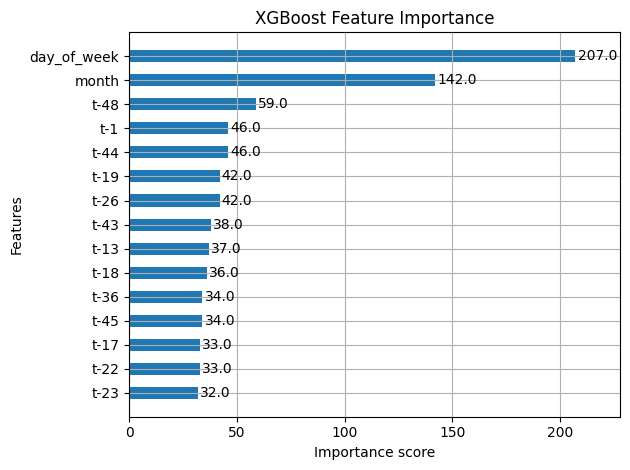

In [19]:
import xgboost as xgb

xgb.plot_importance(best_model_info_f1[0], max_num_features=15, height=0.5) 
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

As we can see, for models trained on windows going across entire days the day_of_week parameter is still by far the most important, possibly due to the fact that not much can be learned about 10pm from the previous night about rush hour at 5pm the next day. To contrast this with our original model with W = 4 and H = 2 from the start of the file we see this:

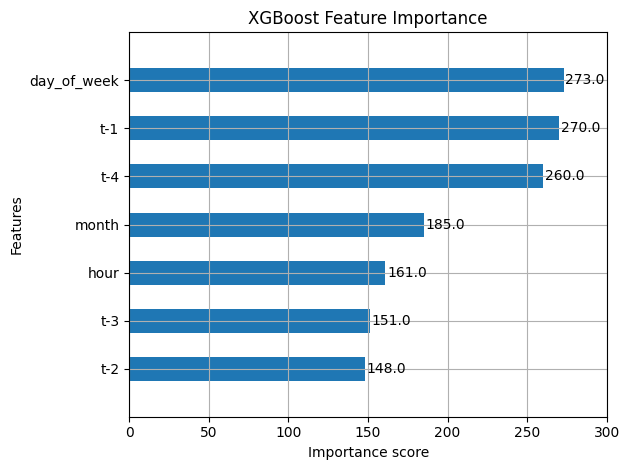

In [20]:
import xgboost as xgb

xgb.plot_importance(model, max_num_features=15, height=0.5) 
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

Although day_of_week maintains the most importance in prediction we see that 30 min to 2 hours beofre becomes significantly more important meaning that if our window is smaller the information from the immediate past is far more valuable for the final prediction. When analyzing more diverse features, this can enable us to potentially identify a root cause of the anomaly and be able to try work around these issues to reduce the frequency of anomalies in the future. In conclusion, there are many tradeoffs that have to be analyzed and fit to the task. Overall, there are many models and approaches that can be utilized to solve this task but I hope this short insight guided you through a standard reasoning process and how to look into solving potential issues that arise when training and evaluating such a model. 